In [1]:
# Step 1: Specify the path to the "experiment_analyses" folder in your system (after cloning the repo)
# This step is because I have a separate folder in the repo that contains the Jupyter Notebooks for organization purposes
import warnings
import os
experiment_analyses_dir = r"C:\Users\graci\OneDrive\Documents\Github\driving_exp_1_analyses\experiment_analyses"  # Replace with your desired directory
os.chdir(experiment_analyses_dir)


# Step 2: Specify the location of file paths contain the main_data folder
# I will share a Dropbox folder with you that contains these folders, so you can just copy and paste your file system file path to these
# Note that the files in these folders should be treated as immutable
import preprocess
import barycenter_functions

SUBJECT_PATH = "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 3/data/main_data" # Dropbox directory path that leads to the csv files for all subejcts across both familiar and unfamiliar group

# subject_dict: all keys are of each subject's id (e.g. "wad") and all values are of the subject_object (which will contain all the data for the subject)

warnings.filterwarnings("ignore")
subject_dict = preprocess.run(SUBJECT_PATH)

In [2]:
# Useful references -------------------------
# Define experimental groups and initialize average cost storage
control_group_ids = ["agony","both","cargo","cheek","cub","desk","dingy","fetch","final","floss","fried","mount","pagan","slot","snarl","spoof","tribe","untie","width","wish"]
scrambled_segments_group_ids = ["brave","comic","crop","dial","donor","even","gave","gore","gray","hump","jury","mud","outer","ozone","relax","riot","salon","unit","upon","zebra"]
scrambled_landmarks_group_ids = ["arena","chain","cloth","crept","disk","elm","flask","flip","game","grab","grant","guy","jam","line","marry","ounce","river","roar","shred","spoon"]

group_ids = [control_group_ids,scrambled_segments_group_ids,scrambled_landmarks_group_ids]
track_pieces_of_interest = ['symmetric_parabolic','t_turn'] # track segments for trial 10 analysis


In [3]:
# get trajectories (trimmed for RESETS) for both track segments
sym_parab_dict = barycenter_functions.process_groups(subject_dict,"symmetric_parabolic",group_ids)
t_turn_dict = barycenter_functions.process_groups(subject_dict,"t_turn",group_ids)

In [4]:
# Get objects associated with a given subject and their trial
subject_object = subject_dict["agony"] 
trial_object_ten = subject_object.trials[9]

# Get track objects for later functions...
sym_parab_object = trial_object_ten.pieces['symmetric_parabolic'] # get the track piece object associated to the track piece
t_turn_object = trial_object_ten.pieces['t_turn'] # get the track piece object associated to the track piece

In [22]:
import matplotlib.pyplot as plt

def plot_trajectories_for_all_group(group_dict,track_piece_object):
    plt.figure(figsize=(12, 8))

    control_trajectories = group_dict["control"][1]
    scrambled_segments_trajectories = group_dict["scrambled_segments"][1]
    scrambled_landmarks_trajectories = group_dict["scrambled_landmarks"][1]

    # Plot all subject trajectories  
    for i, traj in enumerate(scrambled_segments_trajectories):
        if i == 0:
            plt.plot(traj[:, 0], traj[:, 1], lw=1, color='green', label='Scrambled Segments Group Trajectories', alpha=0.6)
        else:
            plt.plot(traj[:, 0], traj[:, 1], lw=1, color='green', alpha=0.6)

    for i, traj in enumerate(scrambled_landmarks_trajectories):
        if i == 0:
            plt.plot(traj[:, 0], traj[:, 1], lw=1, color='red', label='Scrambled Landmarks Group Trajectories', alpha=0.6)
        else:
            plt.plot(traj[:, 0], traj[:, 1], lw=1, color='red', alpha=0.6)

    for i, traj in enumerate(control_trajectories):
        if i == 0:
            plt.plot(traj[:, 0], traj[:, 1], lw=1, color='blue', label='Control Group Trajectories', alpha=0.6)
        else:
            plt.plot(traj[:, 0], traj[:, 1], lw=1, color='blue', alpha=0.6)

    # Get the centerline for reference
    track_piece_center_x, track_piece_center_y = track_piece_object.centerline_df['x'],track_piece_object.centerline_df['y']
    plt.plot(track_piece_center_x, track_piece_center_y, color='black', linestyle='dotted', lw=3, label='Road Center')

    # Plotting labels
    plt.title(f'Trajectories on Trial 10 for {track_piece_object.id}')
    plt.xlabel('X Position')
    plt.ylabel('Z Position')
    
    # Other Plotting params
    ax = plt.gca()
    ax.autoscale()
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    #plt.show()
    plt.savefig(f"C:/Users/graci/Dropbox/PAndA/Thesis Experiment 3/presentations/r_analyses/{track_piece_object.id}_all_trajectories.svg")


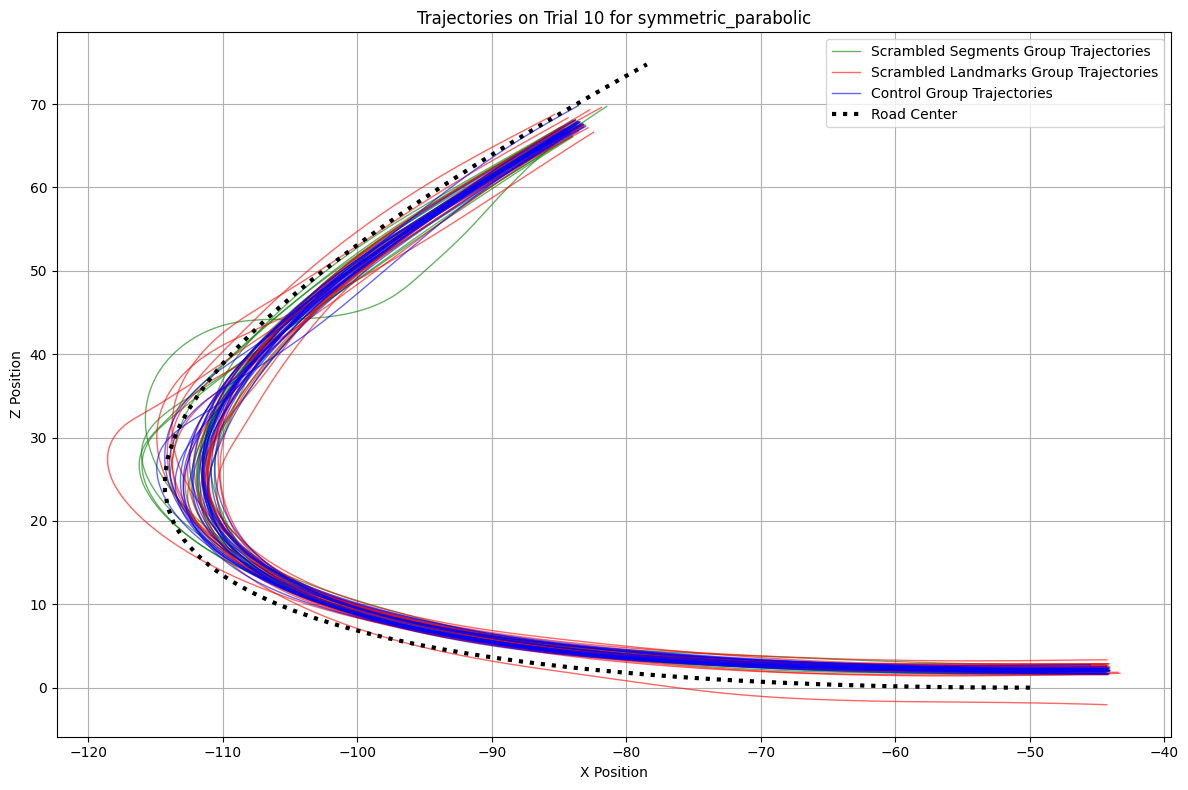

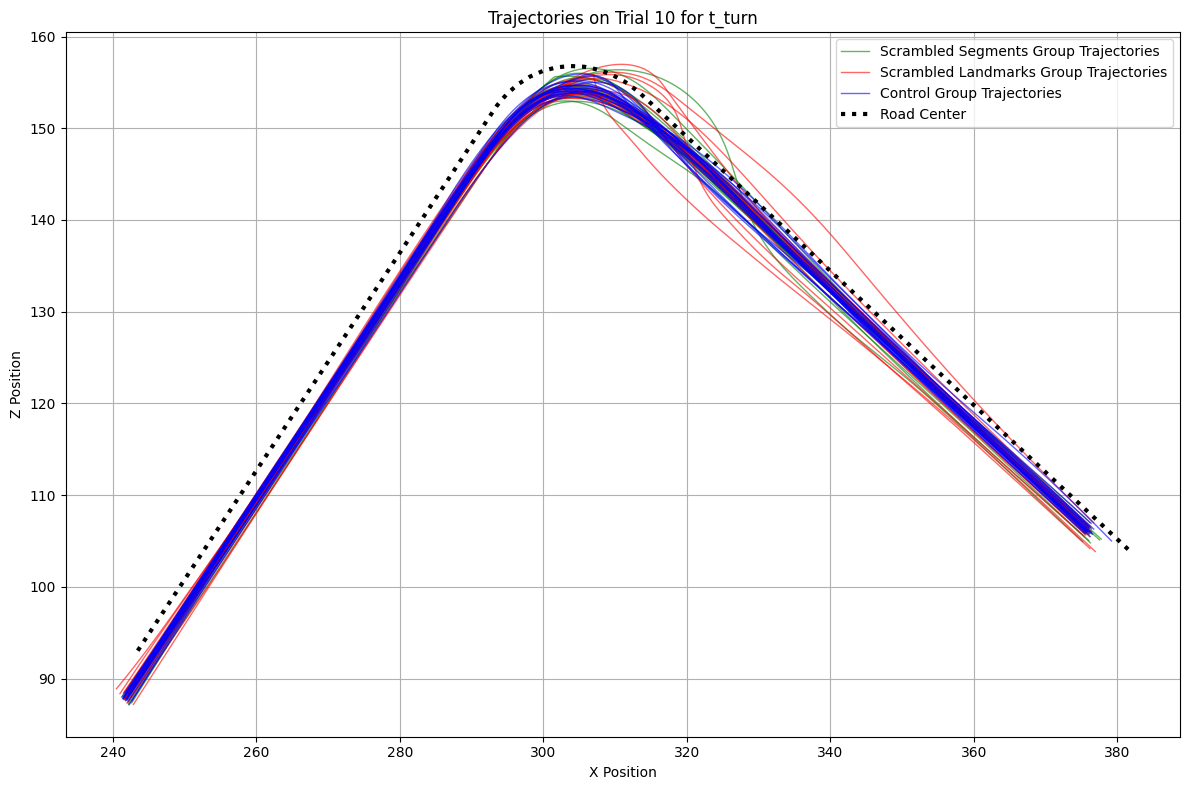

In [23]:
plot_trajectories_for_all_group(sym_parab_dict,sym_parab_object)
plot_trajectories_for_all_group(t_turn_dict,t_turn_object)


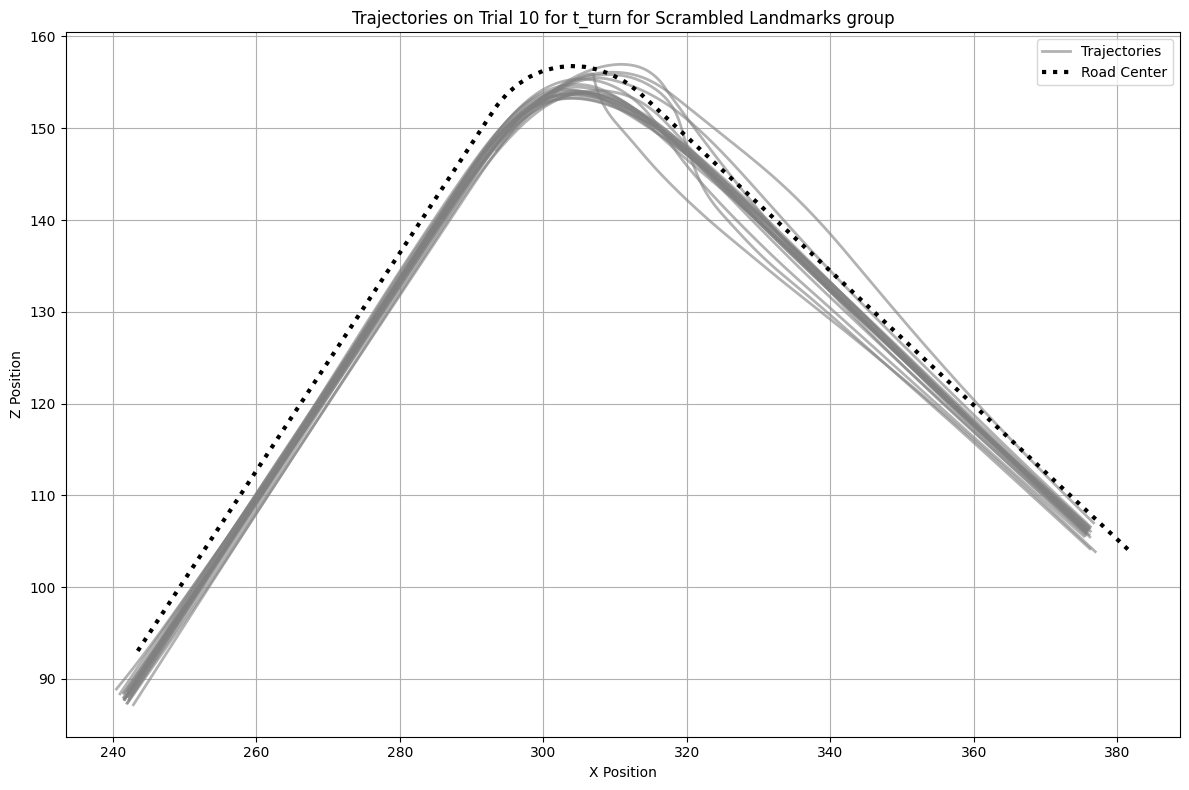

In [ ]:
# To visualize all trajectories... 
#plot_trajectories_for_group("Control",sym_parab_dict["control"][1],sym_parab_object)
#plot_trajectories_for_group("Scrambled Segments",sym_parab_dict["scrambled_segments"][1],sym_parab_object)
#plot_trajectories_for_group("Scrambled Landmarks",sym_parab_dict["scrambled_landmarks"][1],sym_parab_object)
#plot_trajectories_for_group("Control",t_turn_dict["control"][1],t_turn_object)
#plot_trajectories_for_group("Scrambled Segments",t_turn_dict["scrambled_segments"][1],t_turn_object)
#plot_trajectories_for_group("Scrambled Landmarks",t_turn_dict["scrambled_landmarks"][1],t_turn_object)


In [7]:
# get barycenters
# barycenter_functions.get_barycenter_per_group("Constant Track",sym_parab_object,sym_parab_familiar_trajectories,familiar_group_ids)
# barycenter_functions.get_barycenter_per_group("Variable Track",sym_parab_object,sym_parab_unfamiliar_trajectories,unfamiliar_group_ids)
# barycenter_functions.get_barycenter_per_group("Constant Track",t_turn_object,t_turn_familiar_trajectories,familiar_group_ids)
# barycenter_functions.get_barycenter_per_group("Variable Track",t_turn_object,t_turn_unfamiliar_trajectories,unfamiliar_group_ids)

In [8]:
# To visualize barycenter comparison and all trajectories
# barycenter_functions.plot_comp_of_barycenters_and_trajectories(sym_parab_familiar_trajectories,sym_parab_unfamiliar_trajectories, sym_parab_object)
# barycenter_functions.plot_comp_of_barycenters_and_trajectories(t_turn_familiar_trajectories,t_turn_unfamiliar_trajectories,t_turn_object)

In [9]:
# To visualize barycenter comparison
# barycenter_functions.plot_comp_of_barycenters(sym_parab_object)
# barycenter_functions.plot_comp_of_barycenters(t_turn_object)